In [1]:
from imports import qtlab_data
from imports import dataclass
from imports import physics_models
import numpy as np
import os

## Find the Data

In [23]:
data_dir = r"C:\\Users\\oums1095\\Nexus365\\Simen Sopp - OxNanoSpin Team Folder\\Transport\\Ale01_r31\\5.Temperature_Dataset\copy_justSD_Aug"
fig_dir = r"C:\\Users\\oums1095\\projects\\gnr_set\\fit"
os.chdir(data_dir)
# find the data
dataset = qtlab_data.QTLab_Dataset.find()

> Updating info timestamp in dataset.


## Load Stability Diagram Data

In [3]:
# load the data, in this case I load just one by indexing the dataset
data = dataset[0].load(qtlab_data.Stability_Diagram, axes=("Vg", "T", "Vsd", "Isd", "t"))
sd = data[0]

>>> Loading ./012748_Ale01_IVsVg_r31.dat


In [4]:
sd['Vsd'].values.shape, sd['Isd'].values.shape

((2001, 801), (2001, 801))

## Data Pre-processing

In [5]:
T = sd['T'].values.mean() # sd is a Pandas df so retrieve the numpy object
print(f"Stability diagram measure at {round(T,2)} K")
sd["Vsd"] *= 1e-3 # the methods want to work in V and not mV
sd.resample(512, 512)
sd.correct_offset() # subtract a (quasi)-zero-bias gate trace
gatetrace = sd.zero_bias_gate_trace() # gatetrace is stil a Stability_Diagram Object

Stability diagram measure at 238.49 K


## EDA Post Pre-processing

In [6]:
fig = dataclass.Figure()

In [7]:
fig.add_subplot(qtlab_data.Subplot_IVsVg(sd, title=f"sd_{T}_K", cmap='plasma')) # plot SD
fig.add_subplot(qtlab_data.Subplot_IVsVg(sd, title=f"sd_{round(T,2)}_K", cmap="plasma")) # plot conductance SD 
fig.add_subplot(qtlab_data.Subplot_GVg(gatetrace, title=f"zbgt_{T}_K", cmap='plasma')) # plot gatetrace

In [8]:
os.chdir(fig_dir)
fig.visualise(save_as='sd_analysis/test_figure_plasma')

C:\Users\oums1095\Dropbox (Personal)\My PC (OUMS-DOTTI)\Documents\ps_analysis_github\testscripts\imports\dataclass.py:691: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=self._pad)
C:\Users\oums1095\Dropbox (Personal)\My PC (OUMS-DOTTI)\Documents\ps_analysis_github\testscripts\imports\dataclass.py:506: MatplotlibDeprecationWarning: 
The get_clim function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use ScalarMappable.get_clim instead.
  np.max(np.abs(subplot["cbar"].get_clim())),


## Manual Fit

In [9]:
from IPython.display import display, clear_output

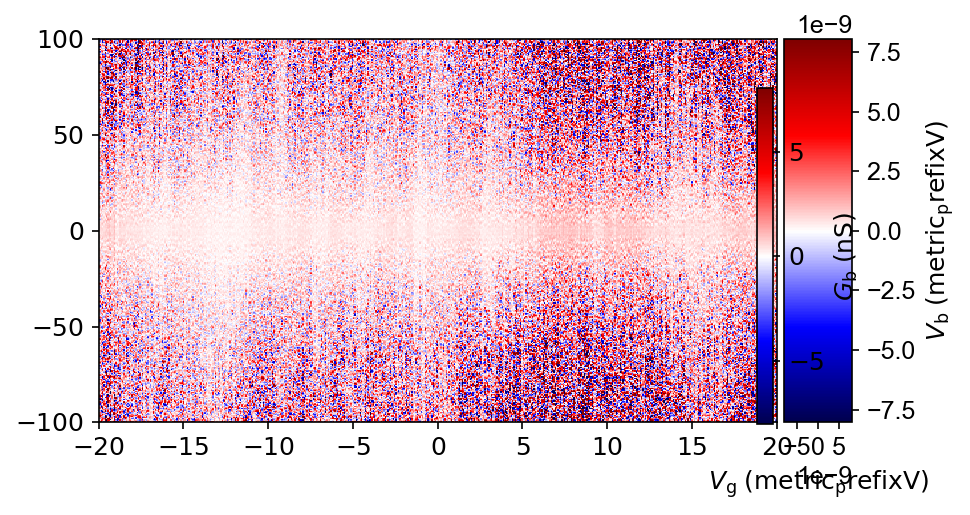

KeyError: 'Vc'

In [10]:
# this method does not work at the moment in a jupyter nb as the figure does not allow the click to be called at runtime
sd.manual_fit_Vc()

In [11]:
vcs = [-15.145847996335647, -9.188144473863547, -2.2866463339701255, 1.7244807900704942, 7.387248494598431, 11.280401291461388]

In [12]:
alpha = 0.023 # meV/V
gatetrace_fits = []
vc = vcs[0]
sd_copy = sd.copy()
setdct = {"Vc": vc, "T": T}
sd_copy.ps(**setdct)
peak_lower_lim = sd_copy[sd_copy["Vg"] > (vc - 2)] 
peak_high_lim = sd_copy[sd_copy["Vg"] > (vc +2)]
gMaxTemp = gatetrace["Gsd"].values[(np.argmin(np.abs(gatetrace["Vg"].values - vc)))]

In [13]:
p0 = {"Vc": vc, "Gmax": gMaxTemp, "alpha": alpha}
bounds = [(vc - 1, 0.5e-11, .85*alpha), (vc + 1, 1.5e-11, 1.15*alpha)]
params, r = sd_copy.fit_coulomb_peak(p0 = p0) 
params["alpha"],params["Gmax"],params["Vc"]

C:\Anaconda\envs\alodi_probestation\lib\site-packages\scipy\optimize\minpack.py:829: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


(-9.391281868705656e-09, 0.3969233934013102, -15.44473405577924)

In [24]:
gatetraceFits = []
params["T"] = T  # add the temperature to the the dictionary of parameters
vg = gatetrace["Vg"].values
fitGsd = physics_models.physics_models.thermal_broadening(vg, **params)  # use the optimised parameters and the gate voltage array to generate the Gsd fit values
gatetraceFit = gatetrace.copy()  # make a copy of the gate trace
gatetraceFit["Gsd"] = fitGsd  # replace the Gsd data with the fitted data
try:
    gatetraceFits.append(gatetraceFit)  # add the fitted gate trace to the list
except:
    pass

gatetraceFitSum = gatetrace.copy()  # make another copy of the gate trace to play with
gatetraceFitSum["Gsd"] -= gatetraceFitSum[
    "Gsd"
].values  # make the Gsd values equal to themselves minus themselves, i.e. make them zero!
for fit in gatetraceFits:  # loop over the fits we added to this list
    gatetraceFitSum["Gsd"] += fit[
        "Gsd"
    ].values  # add the fit values one by one to generate a sum of fits

gatetraceFitSum.ps(
    color="black", label="sum of fits", linewidth=2
)  # change some of the plotting parameters to make it obvious which one is the sum

fig = dataclass.Figure()  # make a figure
fig.add_subplot(
    qtlab_data.Subplot_GVg(gatetrace, *gatetraceFits, gatetraceFitSum, legend=True)
)  # plot the experimental gate traces, and the list of fits all together
fig.visualise(fig_dir) 

In [17]:
dir(physics_models.physics_models)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'curved_stabdiag',
 'improved_marcus',
 'lifetime_broadening',
 'marcus',
 'simmons',
 'spectral_density',
 'stabdiag',
 'stabdiag_improved_marcus',
 'stabdiag_marcus',
 'thermal_broadening']

In [1]:
import pandas as pd
pd.__version__

'1.2.0'

In [2]:
import numpy as np
import scipy as sp
from scipy.special import expit, logit
import scipy.optimize

def f(x,x0,g,c,k):
    y = c*expit(k*10.*(x-x0)) + g*(1.-c)
    return y

#               x0                      g                       c                       k
p0 = np.array([8.841357069490852e-01, 4.492363462957287e-19, 5.547073496706608e-01, 7.435378446218519e+00])
bounds = np.array([[-1.,1.], [0.,1.], [0.,1.], [0.,20.]])
x = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 0.8911796599834791, 1.0, 1.0, 1.0, 0.33232919909076103, 1.0])
y = np.array([0.999, 0.999, 0.999, 0.999, 0.999, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001])
s = np.array([0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9])

print([pval >= b[0] and pval <= b[1] for pval,b in zip(p0,bounds)])

fit,cov = sp.optimize.curve_fit(f,x,y,p0=p0,sigma=s,bounds=([b[0] for b in bounds],[b[1] for b in bounds]),method='dogbox',tr_solver='exact')

print(fit)
print(cov)

[True, True, True, True]
[ 0.89114488  0.          0.55389276 20.        ]
[[ 5.44371881e-04  1.31938960e-02 -5.22733996e-03 -9.46580217e-10]
 [ 1.31938960e-02  1.64386895e+00 -7.33341851e-01 -2.29421487e-08]
 [-5.22733996e-03 -7.33341851e-01  3.63499016e-01  9.08953286e-09]
 [-9.46580217e-10 -2.29421487e-08  9.08953286e-09  1.64595957e-15]]


In [3]:
from scipy.optimize import minimize, Bounds
import numpy as np
import sys

working = True
while working:
    bounds = Bounds(np.array([0.1]), np.array([1.0]))
    n_inputs = len(bounds.lb)
    x0 = np.array(bounds.lb + (bounds.ub-bounds.lb) * np.random.random(n_inputs))
    try:
        minimize(lambda x: np.linalg.norm(x), x0, method='SLSQP', bounds=bounds)
        print('.', end='')
    except:
        ex = sys.exc_info()
        print('\nBang!', ex[0], ex[1])
        working = False
        
x0, bounds

C:\Anaconda\envs\alodi_probestation\lib\site-packages\scipy\optimize\optimize.py:283: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  "minimize step, clipping to bounds", RuntimeWarning)


........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

KeyboardInterrupt: 